In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

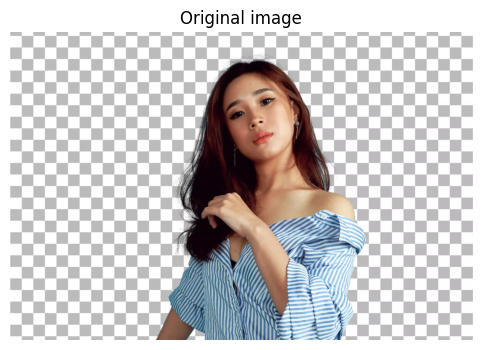

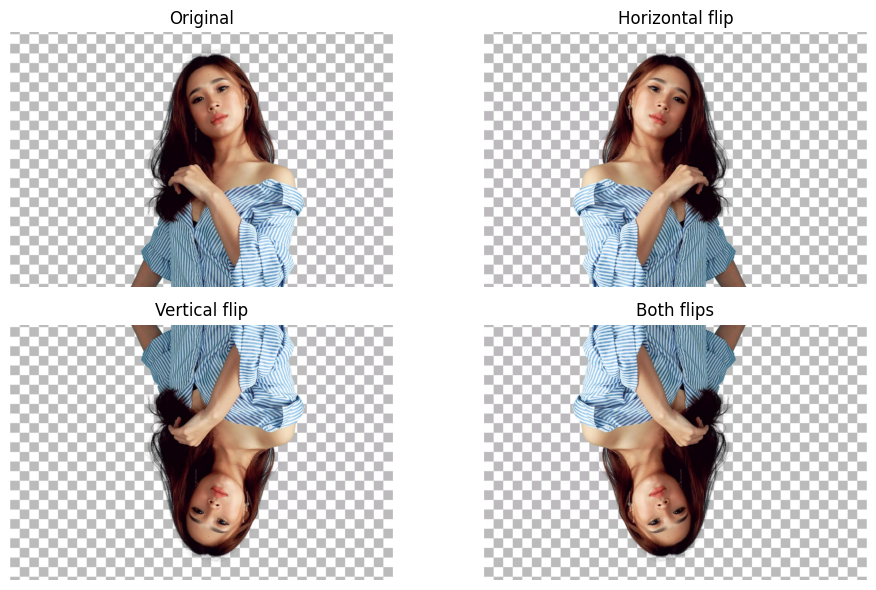

In [2]:
img = cv2.imread("../data/benchmarks/lady.png")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(6,4))
plt.imshow(img_rgb)
plt.title("Original image")
plt.axis("off")
plt.show()

# Horizontal flip
hflip = cv2.flip(img_rgb, 1)

# Vertical flip
vflip = cv2.flip(img_rgb, 0)

# Both directions
hvflip = cv2.flip(img_rgb, -1)

# Show results
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(hflip)
plt.title("Horizontal flip")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(vflip)
plt.title("Vertical flip")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(hvflip)
plt.title("Both flips")
plt.axis("off")

plt.tight_layout()
plt.show()

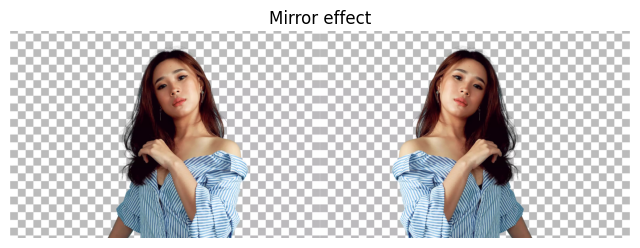

True

In [ ]:
mirror = np.concatenate((img_rgb, hflip), axis=1)

plt.figure(figsize=(8,4))
plt.imshow(mirror)
plt.title("Mirror effect")
plt.axis("off")
plt.show()

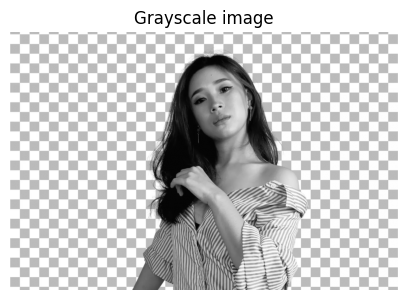

In [4]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(5,4))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")
plt.show()

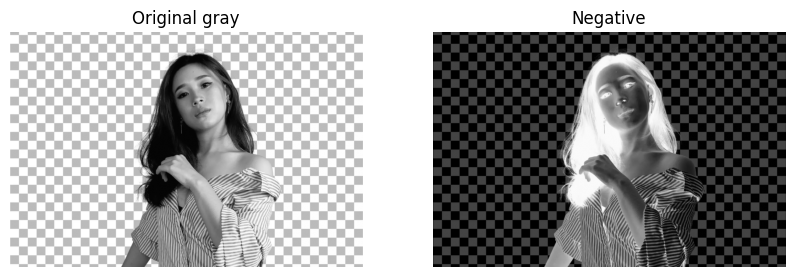

True

In [5]:
negative = 255 - gray

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(negative, cmap='gray')
plt.title("Negative")
plt.axis("off")

plt.show()

# Save
cv2.imwrite("negative.jpg", negative)

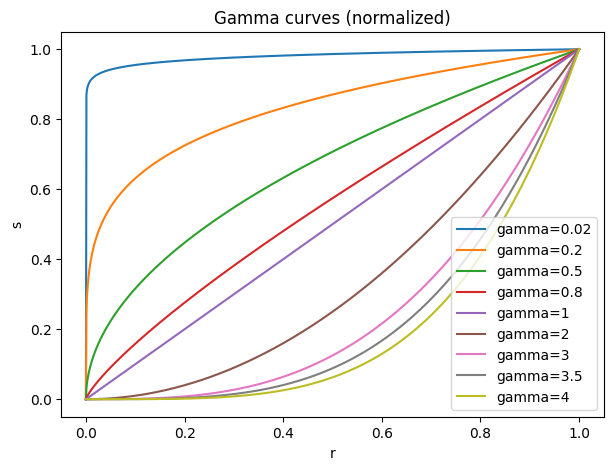

In [6]:
gammas = [0.02, 0.2, 0.5, 0.8, 1, 2, 3, 3.5, 4]

r = np.linspace(0,1,1000)

plt.figure(figsize=(7,5))
for g in gammas:
    s = r**g
    plt.plot(r, s, label=f"gamma={g}")

plt.title("Gamma curves (normalized)")
plt.xlabel("r")
plt.ylabel("s")
plt.legend()
plt.show()

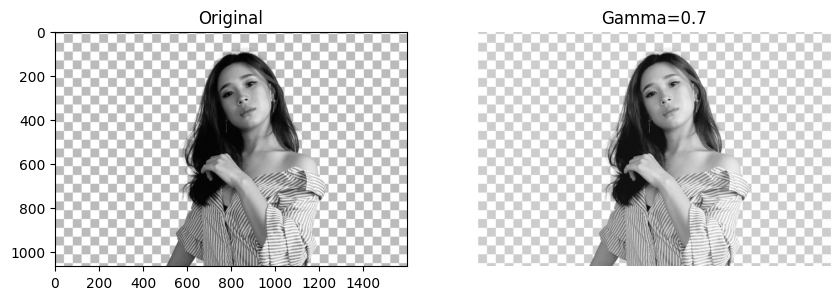

True

In [7]:
gamma = 0.7

# Normalize to [0,1]
gray_norm = gray / 255.0

# Apply gamma
gamma_img = np.power(gray_norm, gamma)

# Back to uint8
gamma_img = np.uint8(gamma_img * 255)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(gamma_img, cmap='gray')
plt.title(f"Gamma={gamma}")

plt.axis("off")
plt.show()

cv2.imwrite("gamma_output.jpg", gamma_img)

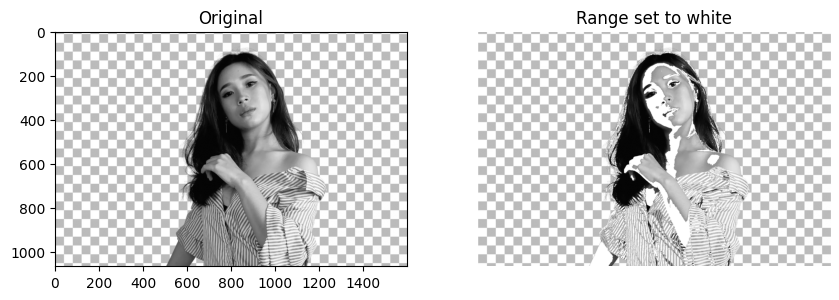

True

In [8]:
A = 80
B = 140

range_img = gray.copy()

mask = (range_img >= A) & (range_img <= B)
range_img[mask] = 255

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(range_img, cmap='gray')
plt.title("Range set to white")

plt.axis("off")
plt.show()

cv2.imwrite("range_output.jpg", range_img)

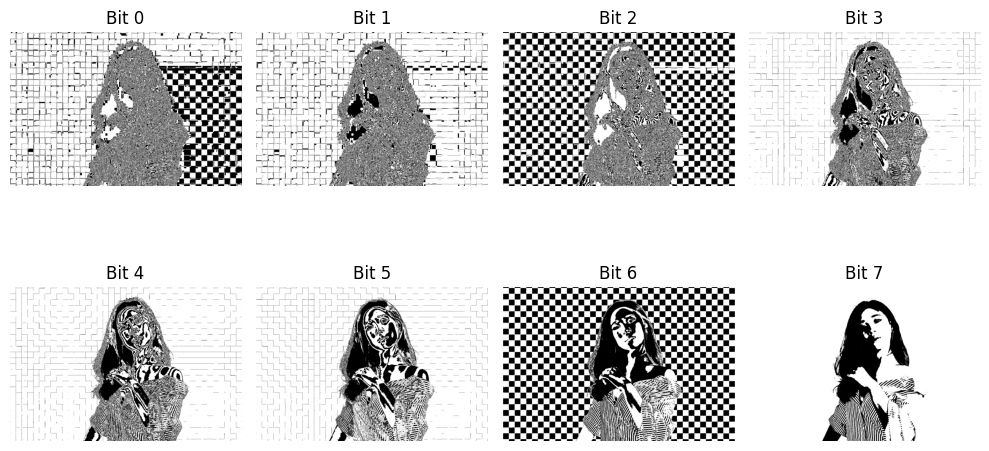

In [9]:
plt.figure(figsize=(10,6))

for k in range(8):
    bit = ((gray >> k) & 1) * 255

    plt.subplot(2,4,k+1)
    plt.imshow(bit, cmap='gray')
    plt.title(f"Bit {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()